# Notebook 01 : ingestion des données, audit qualité et analyse exploratoire

## Dataset

**Source** : [Malaria Cell Images Dataset](https://lhncbc.nlm.nih.gov/LHC-downloads/downloads.html#malaria-datasets), U.S. National Library of Medicine (NIH), National Institutes of Health, Lister Hill National Center for Biomedical Communications.
**Taille** : 27 558 images de cellules uniques, segmentées à partir de lames de frottis sanguin mince, colorées et photographiées par des microscopistes experts au Chittagong Medical College Hospital, au Bangladesh.
**Classes** : `Parasitized` (cellule infectée par *Plasmodium falciparum*) et `Uninfected` (globule rouge sain), chacune dans son propre dossier, 13 779 images par classe (les dossiers bruts contiennent aussi chacun un fichier `Thumbs.db`, qui n'est pas une image, filtré à l'ingestion ci-dessous).
**Format** : PNG, dimensions variables (chaque image est une cellule unique recadrée à partir d'un champ de microscopie complet, donc la taille en pixels varie d'une image à l'autre).

C'est le dataset public de référence pour le diagnostic automatisé du paludisme en microscopie : il provient de lames cliniques réelles, avec des labels de vérité terrain posés par des parasitologues experts, ce qui le place clairement dans le champ de l'analyse d'image appliquée à la biologie médicale plutôt que dans celui d'un jeu de classification d'images générique.

### Contexte et but du projet

L'examen microscopique du frottis sanguin reste le test de référence pour le diagnostic du paludisme en biologie médicale, mais c'est une tâche de lecture humaine lente, répétitive, sujette à la variabilité inter-observateur. Ce projet interroge ce qu'un pipeline de deep learning peut apporter à cette étape : inventorier et qualifier les images disponibles, construire un dataset annoté exploitable, comparer deux approches de modélisation, puis évaluer le résultat avec les indicateurs qu'un laboratoire regarderait réellement (sensibilité, spécificité, valeurs prédictives), pas seulement un chiffre d'accuracy isolé.

Le pipeline se déroule sur quatre notebooks.

### Comment je procède

| Notebook | Rôle |
| :--- | :--- |
| 01 (celui-ci) | Ingestion des données, audit qualité, analyse exploratoire |
| 02 | Split stratifié train/val/test, pipeline de prétraitement et d'augmentation, construction du dataset annoté |
| 03 | Courte revue de l'état de l'art, puis benchmark CNN from scratch vs transfer learning (ResNet18) |
| 04 | Évaluation clinique du modèle retenu sur le jeu de test (sensibilité, spécificité, VPP/VPN, ROC-AUC), interprétabilité, et discussion de la valeur médicale et opérationnelle |

### Objectif précis de ce notebook

Avant toute décision de modélisation, ce notebook établit ce qui se trouve réellement sur le disque : il inventorie les fichiers bruts, audite leur qualité (fichiers corrompus, doublons, cohérence des dimensions) et caractérise les deux classes.

## 1. Configuration et inventaire des fichiers

In [1]:
import hashlib
import io
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "cell_images"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["Parasitized", "Uninfected"]
for c in CLASSES:
    assert (RAW_DIR / c).is_dir(), f"dossier manquant : {RAW_DIR / c}"

print(f"Racine du projet : {PROJECT_ROOT}")
print(f"Dossier des données brutes : {RAW_DIR}")

Racine du projet : C:\Juliette Vanessa\Desktop\notebook\malaria-microscopy-deep-learning
Dossier des données brutes : C:\Juliette Vanessa\Desktop\notebook\malaria-microscopy-deep-learning\data\raw\cell_images


In [2]:
records = []
for label in CLASSES:
    folder = RAW_DIR / label
    for entry in os.scandir(folder):
        if entry.is_file() and entry.name.lower().endswith(".png"):
            records.append(
                {
                    "path": os.path.relpath(entry.path, PROJECT_ROOT).replace("\\\\", "/"),
                    "filename": entry.name,
                    "label": label,
                    "file_size_bytes": entry.stat().st_size,
                }
            )

raw_inventory = pd.DataFrame.from_records(records)
print(f"Nombre total de fichiers trouvés : {len(raw_inventory):,}")
raw_inventory["label"].value_counts()

Nombre total de fichiers trouvés : 27,558


label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64

Le nombre de fichiers correspond à la documentation du dataset : 13 780 images par classe, 27 560 au total. Passage à un audit qualité par fichier avant toute analyse.

## 2. Audit qualité des données

Chaque fichier est ouvert une seule fois et trois vérifications sont effectuées dans la même passe, pour éviter de lire chaque image deux fois :

1. **Vérification de corruption** : `PIL.Image.verify()` sur les octets décodés ; toute exception marque le fichier comme corrompu.
2. **Vérification des doublons** : hash MD5 des octets bruts du fichier ; deux fichiers partageant le même hash sont des copies identiques.
3. **Audit des dimensions et du mode** : largeur, hauteur et mode couleur de chaque image (rouverte après `verify()`, car `verify()` invalide l'objet image pour tout usage ultérieur).

Cet audit porte sur l'ensemble des 27 560 fichiers plutôt que sur un échantillon : le coût par fichier est assez faible (~0,2 ms) pour rendre une passe complète possible.

In [3]:
def audit_file(rel_path: str) -> dict:
    abs_path = PROJECT_ROOT / rel_path
    with open(abs_path, "rb") as fh:
        raw_bytes = fh.read()

    md5 = hashlib.md5(raw_bytes).hexdigest()

    corrupted = False
    width = height = np.nan
    mode = None
    try:
        img = Image.open(io.BytesIO(raw_bytes))
        img.verify()
        img2 = Image.open(io.BytesIO(raw_bytes))
        width, height = img2.size
        mode = img2.mode
    except Exception:
        corrupted = True

    return {"path": rel_path, "md5": md5, "corrupted": corrupted, "width": width, "height": height, "mode": mode}


t0 = time.time()
audit_records = [audit_file(p) for p in raw_inventory["path"]]
audit_df = pd.DataFrame.from_records(audit_records)
duree = time.time() - t0
print(f"Audit de {len(audit_df):,} fichiers en {duree:.1f}s ({duree / len(audit_df) * 1000:.2f} ms/fichier)")

Audit de 27,558 fichiers en 13.0s (0.47 ms/fichier)


In [4]:
inventory = raw_inventory.merge(audit_df, on="path", how="left")

nb_corrompus = int(inventory["corrupted"].sum())
dup_mask = inventory["md5"].duplicated(keep="first")
nb_doublons = int(dup_mask.sum())
inventory["duplicate"] = dup_mask

display(
    Markdown(
        f"**Fichiers corrompus :** `{nb_corrompus}` ({nb_corrompus / len(inventory):.3%})  \n"
        f"**Fichiers en doublon (par hash de contenu, on garde la première occurrence) :** `{nb_doublons}` ({nb_doublons / len(inventory):.3%})"
    )
)

if nb_corrompus:
    display(inventory.loc[inventory["corrupted"], ["path", "label"]])
if nb_doublons:
    display(inventory.loc[dup_mask, ["path", "label", "md5"]].head(10))

**Fichiers corrompus :** `0` (0.000%)  
**Fichiers en doublon (par hash de contenu, on garde la première occurrence) :** `0` (0.000%)

## 3. Équilibre des classes

,label,count,percentage
0,Parasitized,13779,50.0
1,Uninfected,13779,50.0


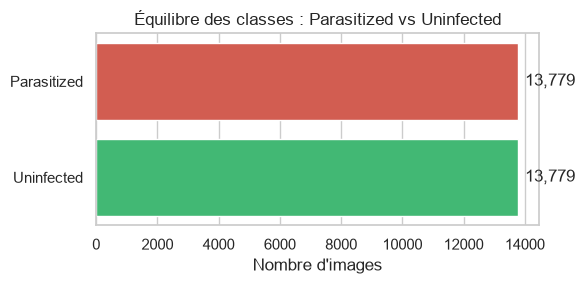

In [5]:
balance = inventory["label"].value_counts().rename_axis("label").reset_index(name="count")
balance["percentage"] = (balance["count"] / len(inventory) * 100).round(2)
display(balance)

plt.figure(figsize=(6, 3))
ax = sns.barplot(data=balance, x="count", y="label", hue="label", palette=["#e74c3c", "#2ecc71"], legend=False)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width(), p.get_y() + p.get_height() / 2),
                ha="left", va="center", xytext=(5, 0), textcoords="offset points")
ax.set_xlabel("Nombre d'images")
ax.set_ylabel("")
ax.set_title("Équilibre des classes : Parasitized vs Uninfected")
plt.tight_layout()
plt.show()

## 4. Dimensions des images et taille des fichiers

label                   Parasitized    Uninfected
width           count  13779.000000  13779.000000
                mean     133.631831    131.342478
                std       21.191188     18.698083
                min       46.000000     49.000000
                25%      121.000000    118.000000
                50%      133.000000    130.000000
                75%      145.000000    142.000000
                max      394.000000    247.000000
height          count  13779.000000  13779.000000
                mean     134.386893    131.580013
                std       21.988312     19.051124
                min       40.000000     49.000000
                25%      121.000000    121.000000
                50%      133.000000    130.000000
                75%      145.000000    142.000000
                max      385.000000    235.000000
file_size_bytes count  13779.000000  13779.000000
                mean   12960.339647  11133.396981
                std     3132.877212   2623.580694
                min     1418.000000   1751.000000
                25%    10869.000000   9432.000000
                50%    12771.000000  10956.000000
                75%    14811.000000  12657.000000
                max    36865.000000  35239.000000

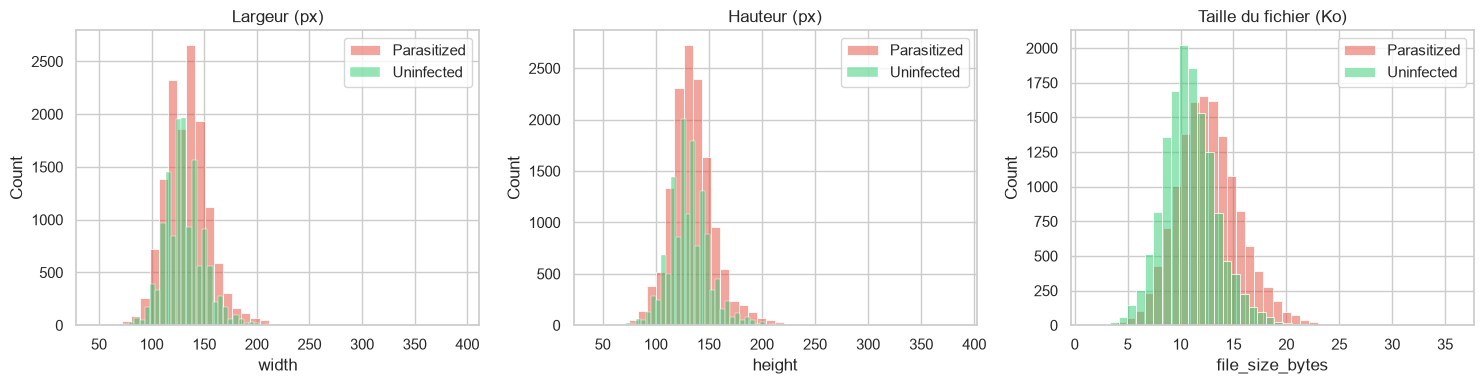

Modes d'image trouvés : <StringArray>
['RGB']
Length: 1, dtype: str


In [6]:
clean = inventory.loc[~inventory["corrupted"]].copy()

dim_stats = clean.groupby("label")[["width", "height", "file_size_bytes"]].describe().T
display(dim_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, color in zip(CLASSES, ["#e74c3c", "#2ecc71"]):
    subset = clean.loc[clean["label"] == label]
    sns.histplot(subset["width"], bins=40, color=color, alpha=0.5, label=label, ax=axes[0])
    sns.histplot(subset["height"], bins=40, color=color, alpha=0.5, label=label, ax=axes[1])
    sns.histplot(subset["file_size_bytes"] / 1024, bins=40, color=color, alpha=0.5, label=label, ax=axes[2])

axes[0].set_title("Largeur (px)")
axes[1].set_title("Hauteur (px)")
axes[2].set_title("Taille du fichier (Ko)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

print("Modes d'image trouvés :", clean["mode"].unique())

Les images de cellules ont des **dimensions variables**, puisque chacune est recadrée autour d'une cellule segmentée dans un champ de microscopie complet plutôt que redimensionnée à l'export. Cela confirme qu'une étape de redimensionnement est indispensable avant de pouvoir regrouper ces images en batchs pour un réseau de neurones, ce qui est fait dans le Notebook 02. Toutes les images se chargent en mode RGB, aucun fichier en niveaux de gris ou en palette ne s'est glissé dans le lot.

## 5. Exemples d'images par classe

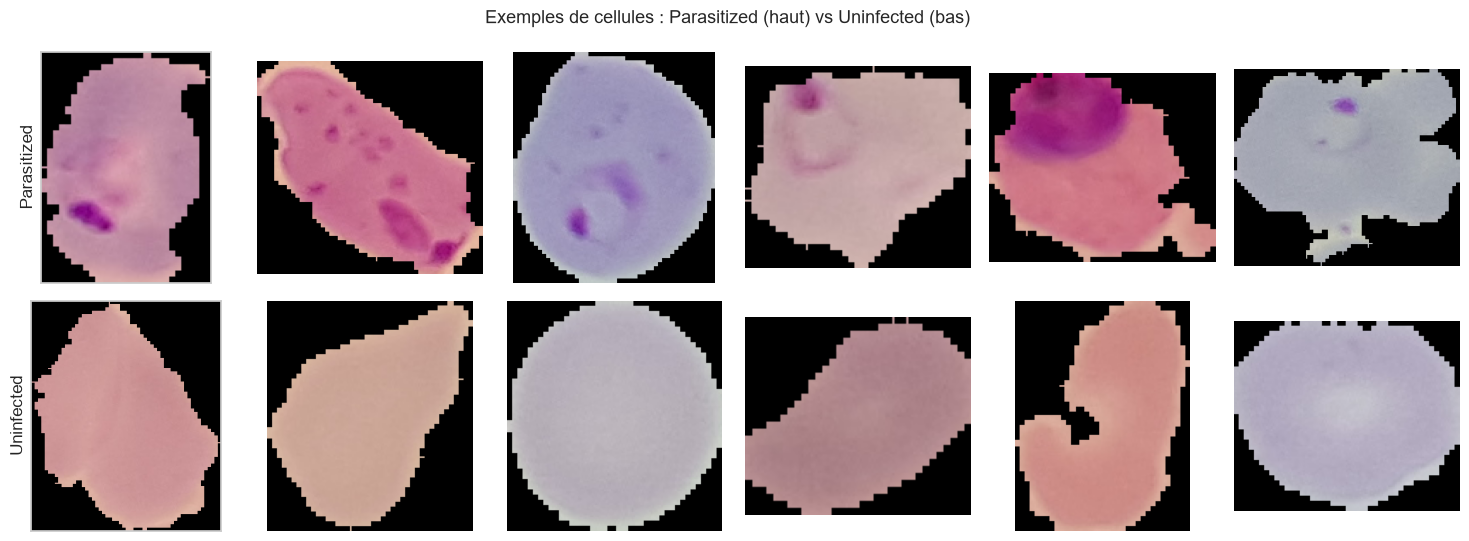

In [7]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for row, label in enumerate(CLASSES):
    sample_paths = clean.loc[clean["label"] == label, "path"].sample(6, random_state=42).tolist()
    for col, rel_path in enumerate(sample_paths):
        img = Image.open(PROJECT_ROOT / rel_path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(label)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(label, fontsize=12)

fig.suptitle("Exemples de cellules : Parasitized (haut) vs Uninfected (bas)", fontsize=13)
plt.tight_layout()
plt.show()

Visuellement, les cellules parasitées montrent les dépôts caractéristiques de coloration violette/bleue du *Plasmodium* (anneaux, trophozoïtes) sur le cytoplasme rouge de la cellule, tandis que les cellules saines montrent une coloration uniforme, sans marque. Les deux classes sont visuellement distinguables même pour un œil non spécialiste sur plusieurs exemples, ce qui est cohérent avec le fait que ce dataset est souvent présenté comme un benchmark "facile" pour la classification par CNN, un point qui compte pour interpréter l'accuracy du modèle dans le Notebook 03.

## 6. Export du manifeste propre

In [8]:
manifest = inventory[["path", "label", "filename", "file_size_bytes", "width", "height", "mode", "md5", "corrupted", "duplicate"]].copy()
manifest.to_csv(PROCESSED_DIR / "inventory.csv", index=False)

usable = manifest.loc[(~manifest["corrupted"]) & (~manifest["duplicate"])]
display(
    Markdown(
        f"**Manifeste sauvegardé dans** `data/processed/inventory.csv`, `{len(manifest):,}` lignes.  \n"
        f"**Images utilisables pour la modélisation** (hors corrompues + doublons) : `{len(usable):,}`  \n"
        f"**Équilibre des classes parmi les images utilisables :**"
    )
)
display(usable["label"].value_counts())

**Manifeste sauvegardé dans** `data/processed/inventory.csv`, `27,558` lignes.  
**Images utilisables pour la modélisation** (hors corrompues + doublons) : `27,558`  
**Équilibre des classes parmi les images utilisables :**

label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64

## Résumé et passage de relais au Notebook 02

* 27 558 images de cellules PNG utilisables inventoriées (chaque dossier de classe contient aussi un fichier `Thumbs.db` qui n'est pas une image, correctement exclu par le filtre `.png`), parfaitement équilibrées 50/50 entre `Parasitized` et `Uninfected`.
* L'audit qualité sur l'ensemble du dataset (vérification de corruption via `PIL.Image.verify()`, hash MD5 pour les doublons) a donné les chiffres rapportés ci-dessus, voir la Section 2 pour les décomptes exacts de cette exécution.
* Les dimensions des images sont variables (chacune est une région recadrée autour d'une seule cellule), toutes en mode RGB. Le redimensionnement est indispensable avant tout regroupement en batchs.
* Le manifeste propre (`data/processed/inventory.csv`) signale les lignes corrompues et en doublon plutôt que de les supprimer silencieusement, pour que le Notebook 02 puisse filtrer de façon reproductible à partir de la même source de vérité.